In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("../data/cleaned/spotify_master_clean.csv")
df.head()

,track_name,energy,tempo,danceability,loudness,liveness,valence,time_signature,speechiness,instrumentalness,mode,key,duration_ms,acousticness,source,artist_name,popularity,track_name_clean,artist_name_clean
0,!!!!,0.258,0.440074,0.758032,0.744005,0.109109,0.0593,0.8,0.087785,0.890,0.0,1.000000,0.024918,0.515060,nov_2018,alicks,0.24,NaN,alicks
1,!!!!!!!,0.278,0.000000,0.000000,0.620814,0.669670,0.0000,0.0,0.000000,0.000,1.0,0.090909,0.001850,0.771084,april_2019,billie eilish,0.33,NaN,billie eilish
2,"""1955",0.437,0.328034,0.317269,0.776171,0.090591,0.0393,0.6,0.037371,0.901,1.0,0.818182,0.033294,0.632530,nov_2018,pablo lópez,0.00,1955,pablo lópez
3,"""42"" - from sr3mm",0.563,0.520191,0.971888,0.861664,0.108108,0.3240,0.8,0.129400,0.000,1.0,0.090909,0.041881,0.002761,nov_2018,rae sremmurd,0.55,42 from sr3mm,rae sremmurd
4,"""99""",0.804,0.383946,0.554217,0.901223,0.111111,0.7140,0.8,0.031366,0.000,1.0,0.727273,0.034995,0.006004,nov_2018,barns courtney,0.64,99,barns courtney


## Analysis 1: Feature Distributions and Scale

In this analysis, we are examining the distributions and numerical scales of Spotify audio features used to represent emotional characteristics of songs. 

In [6]:
audio_features = [
    "energy",
    "valence",
    "tempo",
    "loudness",
    "danceability",
    "acousticness",
    "instrumentalness",
    "liveness",
    "speechiness"
]

X = df[audio_features]
X.head()

,energy,valence,tempo,loudness,danceability,acousticness,instrumentalness,liveness,speechiness
0,0.258,0.0593,0.440074,0.744005,0.758032,0.515060,0.890,0.109109,0.087785
1,0.278,0.0000,0.000000,0.620814,0.000000,0.771084,0.000,0.669670,0.000000
2,0.437,0.0393,0.328034,0.776171,0.317269,0.632530,0.901,0.090591,0.037371
3,0.563,0.3240,0.520191,0.861664,0.971888,0.002761,0.000,0.108108,0.129400
4,0.804,0.7140,0.383946,0.901223,0.554217,0.006004,0.000,0.111111,0.031366


In [7]:
X.describe()

,energy,valence,tempo,loudness,danceability,acousticness,instrumentalness,liveness,speechiness
count,109926.000000,109926.000000,109926.000000,109926.000000,109926.000000,109926.000000,109926.000000,109926.000000,109926.000000
mean,0.563684,0.444226,0.476453,0.804780,0.578174,0.356527,0.235821,0.197555,0.115216
std,0.266308,0.263125,0.120768,0.110491,0.194395,0.353333,0.367041,0.171134,0.129288
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.382000,0.223000,0.382862,0.771612,0.450803,0.033434,0.000000,0.097497,0.040269
50%,0.602000,0.426000,0.480085,0.839579,0.601406,0.217871,0.000212,0.124124,0.057143
75%,0.777000,0.649000,0.553522,0.878167,0.727912,0.672691,0.537000,0.241241,0.130435
max,1.000000,1.000000,1.000000,0.999094,1.000000,1.000000,1.000000,1.000000,1.000000


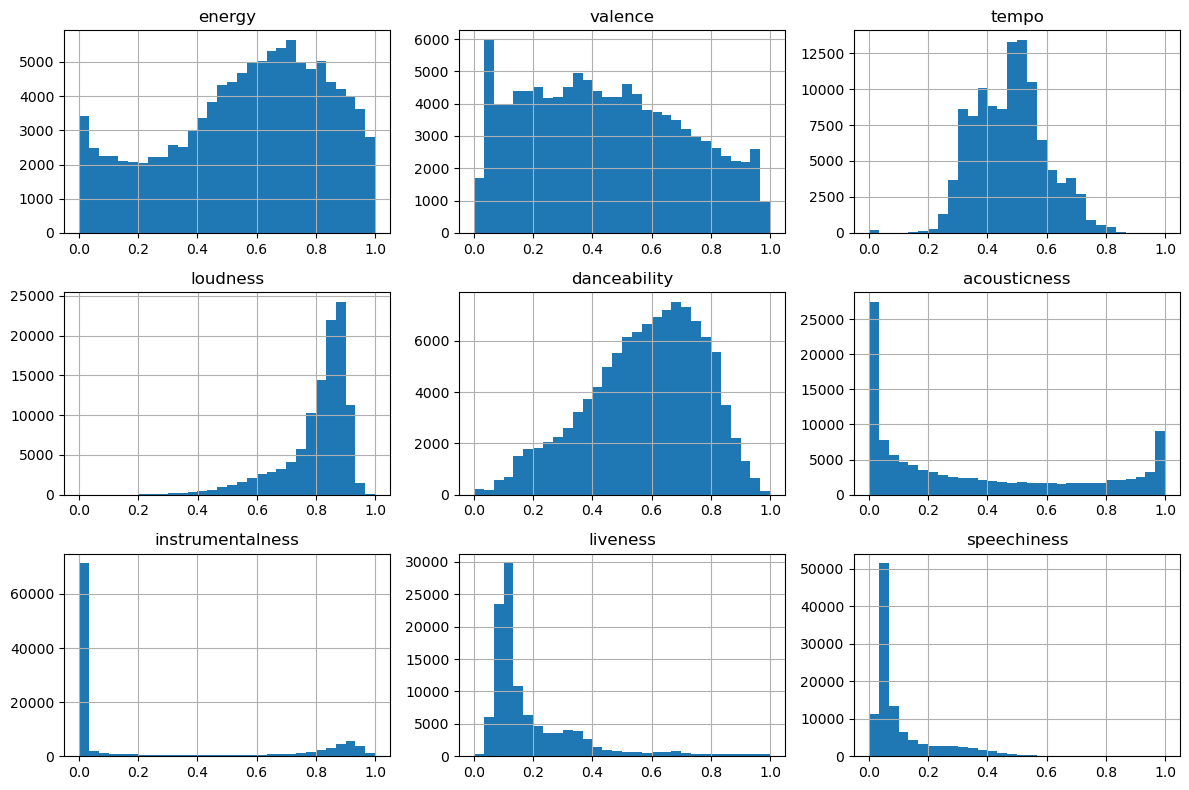

In [8]:
X.hist(bins=30, figsize=(12, 8))
plt.tight_layout()

**Conclusion (Analysis 1):**  
Although all audio features are scaled between 0 and 1, they behave very differently in practice. Some features, such as energy and danceability, vary smoothly across many songs, while others, like instrumentalness, speechiness, and liveness, are heavily concentrated near zero with only a few extreme values. This means that certain features could unintentionally have a much larger influence when comparing songs . As a result, features will need to be normalized and potentially weighted differently later, depending on how emotional scores are defined.

## Analysis 2: Feature Relationships (Correlation)

In this analysis, we examine relationships between audio features to identify correlations and potential redundancy. 

In [9]:
corr = X.corr()
corr

,energy,valence,tempo,loudness,danceability,acousticness,instrumentalness,liveness,speechiness
energy,1.000000,0.329951,0.238768,0.778692,0.320105,-0.723670,-0.321383,0.209753,0.113140
valence,0.329951,1.000000,0.113782,0.338377,0.478129,-0.191293,-0.267279,-0.006751,0.123640
tempo,0.238768,0.113782,1.000000,0.229520,0.093087,-0.223008,-0.093952,-0.004397,0.052330
loudness,0.778692,0.338377,0.229520,1.000000,0.456958,-0.618412,-0.515042,0.072041,0.083699
danceability,0.320105,0.478129,0.093087,0.456958,1.000000,-0.383062,-0.318518,-0.129617,0.253133
acousticness,-0.723670,-0.191293,-0.223008,-0.618412,-0.383062,1.000000,0.285039,-0.107764,-0.128475
instrumentalness,-0.321383,-0.267279,-0.093952,-0.515042,-0.318518,0.285039,1.000000,-0.077149,-0.225239
liveness,0.209753,-0.006751,-0.004397,0.072041,-0.129617,-0.107764,-0.077149,1.000000,0.114483
speechiness,0.113140,0.123640,0.052330,0.083699,0.253133,-0.128475,-0.225239,0.114483,1.000000


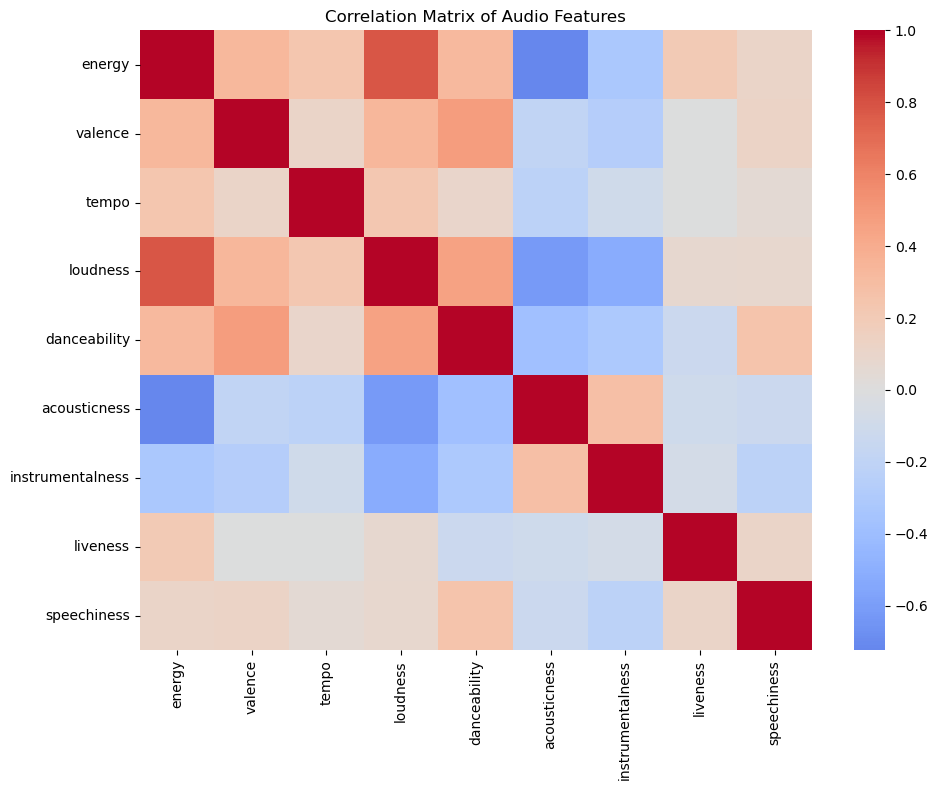

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Matrix of Audio Features")
plt.tight_layout()

**Conclusion (Analysis 2):**  
The correlation analysis reveals both strong positive and strong negative relationships between audio features. Features such as energy, loudness, and danceability are positively correlated, indicating that they often increase together and may describe similar aspects of musical intensity. In contrast, acousticness shows strong negative correlations with energy and loudness, suggesting that it represents an opposing spects of musical intensity. Other features, including instrumentalness, speechiness, and liveness, exhibit weaker correlations and appear to capture more independent properties. Together, these results indicate that the audio feature space contains both simila and opposing signals which will be important for careful weighting in later modeling stages.